In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
conn = sqlite3.connect("../database/ecommerce.db")
customers = pd.read_sql_query(
    "SELECT * FROM customers",
    conn
)
products = pd.read_sql_query(
    "SELECT * FROM Products",
    conn
)
orders = pd.read_csv("../data/Orders.csv")
payments = pd.read_csv("../data/Payments.csv")
merged = orders.merge(
    products,
    on="product_id"
)
merged["revenue"] = (
    merged["quantity"] *
    merged["price"]
)
merged["order_date"] = pd.to_datetime(
    merged["order_date"]
)
merged["month_name"] = (
    merged["order_date"]
    .dt.month_name()
)
merged["day_name"] = (
    merged["order_date"]
    .dt.day_name()
)

In [2]:
customer_revenue=(
    merged.groupby(
        "customer_id"
    )["revenue"].sum().reset_index()
)
customer_revenue.head()

,customer_id,revenue
0,1,79999.0
1,2,798.0
2,3,4999.0
3,4,3499.0
4,5,69999.0


In [5]:
customer_revenue=(
    customer_revenue.sort_values(by = "revenue",ascending=False))

In [7]:
customer_revenue["segment"] = pd.qcut(
    customer_revenue["revenue"],
    q=3,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ]
)
customer_revenue.head()

,customer_id,revenue,segment
0,1,79999.0,High Value
10,11,79999.0,High Value
4,5,69999.0,High Value
16,17,69999.0,High Value
18,19,9998.0,High Value


In [8]:
customer_revenue["segment"].value_counts()

segment
Low Value       7
High Value      7
Medium Value    6
Name: count, dtype: int64

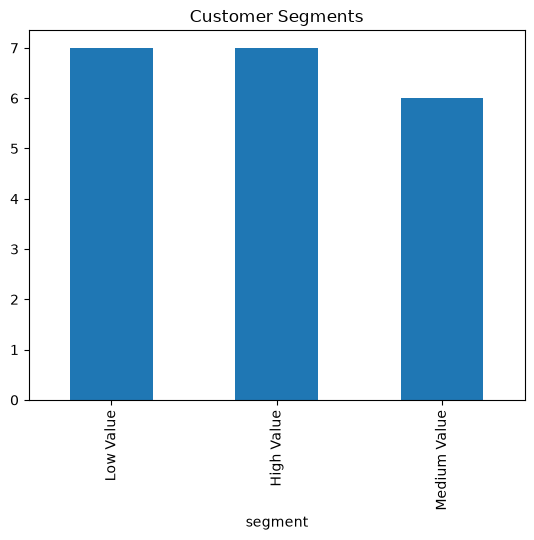

In [9]:
customer_revenue["segment"
].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.show()

In [10]:
segment_revenue = (
    customer_revenue.groupby("segment")["revenue"].sum())
segment_revenue

C:\Users\SYED MOHD HAMZA\AppData\Local\Temp\ipykernel_24720\1421032360.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_revenue.groupby("segment")["revenue"].sum())


segment
Low Value         9784.0
Medium Value     19092.0
High Value      320992.0
Name: revenue, dtype: float64

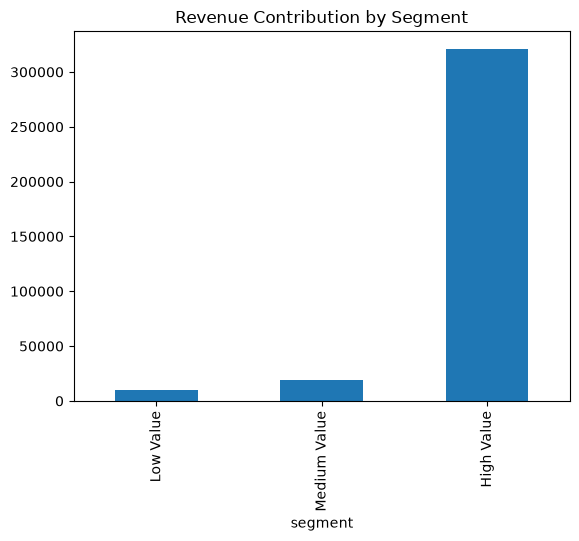

In [11]:
segment_revenue.plot(
    kind="bar"
)

plt.title(
    "Revenue Contribution by Segment"
)

plt.show()

In [12]:
customer_revenue.head(10)

,customer_id,revenue,segment
0,1,79999.0,High Value
10,11,79999.0,High Value
4,5,69999.0,High Value
16,17,69999.0,High Value
18,19,9998.0,High Value
14,15,5999.0,High Value
2,3,4999.0,High Value
7,8,3998.0,Medium Value
19,20,3499.0,Medium Value
3,4,3499.0,Medium Value


In [13]:
'''Insight 1:
High Value customers generate majority revenue.

Insight 2:
Low Value customers contribute little revenue.

Insight 3:
Business should focus retention efforts on High Value customers.

Insight 4:
Medium Value customers can be converted into High Value customers through targeted promotions.'''

'Insight 1:\nHigh Value customers generate majority revenue.\n\nInsight 2:\nLow Value customers contribute little revenue.\n\nInsight 3:\nBusiness should focus retention efforts on High Value customers.\n\nInsight 4:\nMedium Value customers can be converted into High Value customers through targeted promotions.'